# Scalability Test Summary – Hybrid Standard Learning Model

This notebook summarizes **final overall results** from scalability experiments
for different world sizes, agent count and obstacle ratios.

We only use the final aggregated metrics:

- `Success Rate`
- `Collision Rate`
- `Avg Steps per Episode`
- `Overall Agent Completion Rate`

We evaluate these metrics separately for:

- **RAW ACTION MODE**  
- **FILTERED ACTION MODE**

And then compare the two modes to understand performance differences.
World sizes currently compared:

- **70 × 70**
- **160 × 160**



In [91]:
import re
import pandas as pd
import matplotlib.pyplot as plt


# Parser for Raw action Mode results

In [92]:
def parse_final_results(file_path):
    

    patterns = {
        "success_rate": re.compile(r"Success Rate:\s*([0-9.]+)%"),
        "collision_rate": re.compile(r"Collision Rate:\s*([0-9.]+)%"),
        "avg_steps": re.compile(r"Avg Steps per Episode:\s*([0-9.]+)"),
        "completion_rate": re.compile(r"Overall Agent Completion Rate:\s*([0-9.]+)%"),
    }

    results = {
        "file_path": file_path
    }

    with open(file_path, "r") as f:
        text = f.read()

    blocks = text.split("ALL EXPERIMENTS DONE")
    if len(blocks) < 2:
        raise ValueError(f"'ALL EXPERIMENTS DONE' not found in {file_path}")

    raw_block = blocks[1]  # text immediately after first ALL EXPERIMENTS DONE

    for key, pattern in patterns.items():
        m = pattern.search(raw_block)
        if not m:
            raise ValueError(f"Could not find {key} in RAW summary block of {file_path}")
        results[key] = float(m.group(1))

    # Extract world size from any "World size:" line in the file
    world_pattern = re.compile(r"World size:\s*(\d+)")
    m_world = world_pattern.search(text)
    if m_world:
        results["world_size"] = int(m_world.group(1))
    else:
        results["world_size"] = None

    return results


# file paths + parsing  (Raw action Mode)

Update the paths if your folder names differ.

In [93]:
# Paths to txt files with results
path_160 = "Experimental_results_of_Different_models/Hybrid_Standard_Learning_model/scalability_test_size160x160_agents_1000_obs_20_envs/scalability_test_size160x160_agents_1000_obs_20_results.txt"

path_70 = "Experimental_results_of_Different_models/Hybrid_Standard_Learning_model/scalability_test_size70x70_agents_1000_obs_20_envs/scalability_test_size70x70_agents_1000_obs_20_results.txt"

res_160 = parse_final_results(path_160)
res_70 = parse_final_results(path_70)

df_summary = pd.DataFrame([res_70, res_160])

# Sorted by world size
df_summary = df_summary.sort_values("world_size").reset_index(drop=True)
df_summary


,file_path,success_rate,collision_rate,avg_steps,completion_rate,world_size
0,Experimental_results_of_Different_models/Hybri...,0.0,4.91,512.0,70.80,70
1,Experimental_results_of_Different_models/Hybri...,0.0,1.23,512.0,81.25,160


## Summary of Final Overall Results for Raw action Mode

The table below summarizes the **final aggregated metrics** for each world size
(using RAW ACTION MODE results only):

- **Success Rate (%)**
- **Collision Rate (%)**
- **Avg Steps per Episode**
- **Overall Agent Completion Rate (%)**


In [94]:
df_summary.style.format({
    "success_rate": "{:.2f}",
    "collision_rate": "{:.2f}",
    "avg_steps": "{:.2f}",
    "completion_rate": "{:.2f}",
})


,file_path,success_rate,collision_rate,avg_steps,completion_rate,world_size
0,Experimental_results_of_Different_models/Hybrid_Standard_Learning_model/scalability_test_size70x70_agents_1000_obs_20_envs/scalability_test_size70x70_agents_1000_obs_20_results.txt,0.00,4.91,512.00,70.80,70
1,Experimental_results_of_Different_models/Hybrid_Standard_Learning_model/scalability_test_size160x160_agents_1000_obs_20_envs/scalability_test_size160x160_agents_1000_obs_20_results.txt,0.00,1.23,512.00,81.25,160


## Comparison Plots  for Raw action Mode

For each metric, we compare the values across different world sizes:

1. Success Rate vs World Size  
2. Collision Rate vs World Size  
3. Avg Steps per Episode vs World Size  
4. Overall Agent Completion Rate vs World Size  

Since world size is the only varying parameter here, we use simple bar charts.



# Success Rate vs World Size for Raw action Mode

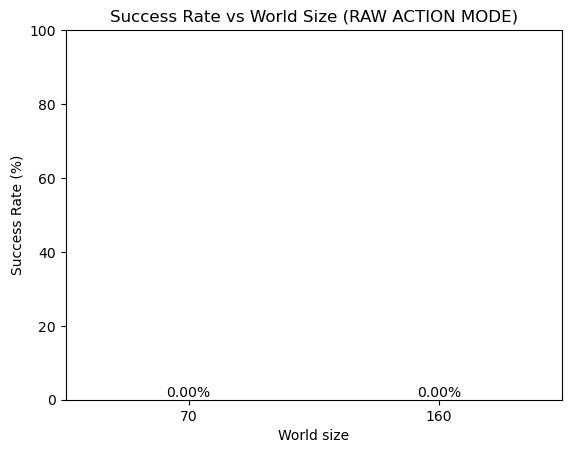

In [95]:
plt.figure()
bars = plt.bar(df_summary["world_size"].astype(str), df_summary["success_rate"])

plt.xlabel("World size")
plt.ylabel("Success Rate (%)")
plt.title("Success Rate vs World Size (RAW ACTION MODE)")

# Force common Y-axis scale for percentages
plt.ylim(0, 100)
plt.yticks([0, 20, 40, 60, 80, 100])

# Add numeric labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha='center', va='bottom',
        fontsize=10
    )

plt.show()


# Collision Rate vs World Size for Raw action Mode

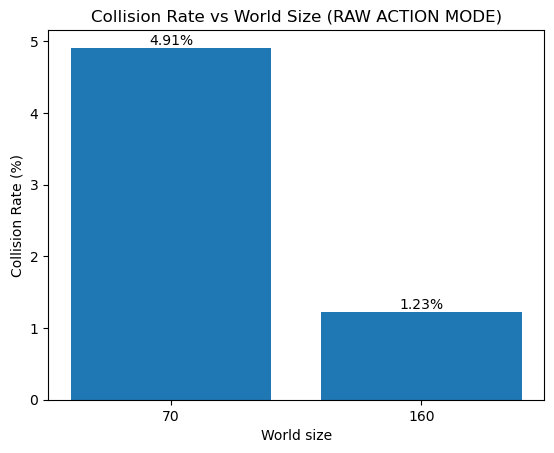

In [96]:
plt.figure()
bars = plt.bar(df_summary["world_size"].astype(str), df_summary["collision_rate"])

plt.xlabel("World size")
plt.ylabel("Collision Rate (%)")
plt.title("Collision Rate vs World Size (RAW ACTION MODE)")

# --- ONLY write values on top of bars ---
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha='center', va='bottom', fontsize=10
    )

plt.show()


# Avg Steps vs World Size for  Raw action Mode

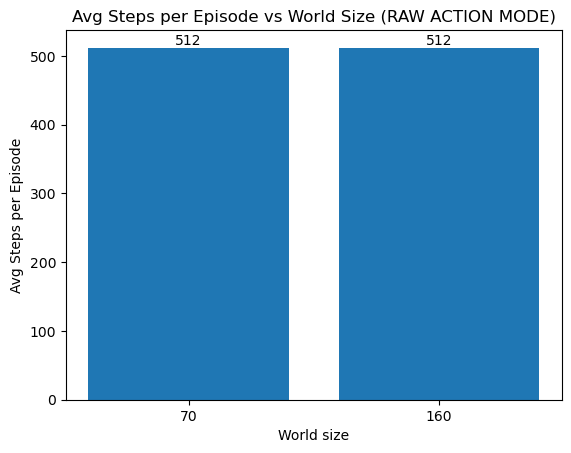

In [97]:
plt.figure()
bars = plt.bar(df_summary["world_size"].astype(str), df_summary["avg_steps"])

plt.xlabel("World size")
plt.ylabel("Avg Steps per Episode")
plt.title("Avg Steps per Episode vs World Size (RAW ACTION MODE)")

# --- Add value labels on top of bars ---
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.0f}",   # whole number (steps)
        ha='center', va='bottom', fontsize=10
    )

plt.show()


# Agent Completion Rate vs World Size for  Raw action Mode

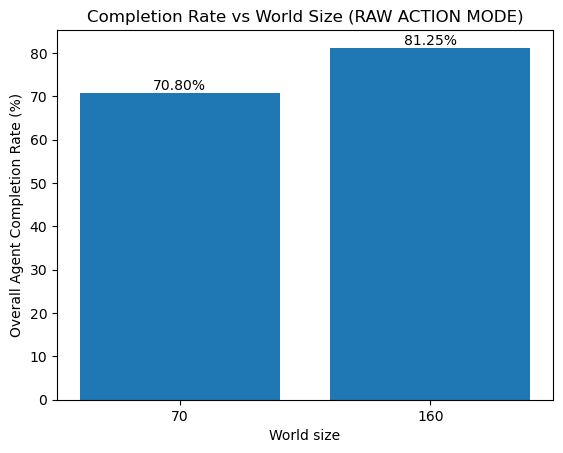

In [98]:
plt.figure()
bars = plt.bar(df_summary["world_size"].astype(str), df_summary["completion_rate"])

plt.xlabel("World size")
plt.ylabel("Overall Agent Completion Rate (%)")
plt.title("Completion Rate vs World Size (RAW ACTION MODE)")

# --- Add value labels on top of bars ---
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha='center', va='bottom', fontsize=10
    )

plt.show()


## Filtered Action Mode – Final Overall Results (70×70 vs 160×160)

In this section we:

- Parse **only the FILTERED ACTION MODE final summary** from each results file.
- Extract:
  - Success Rate (%)
  - Collision Rate (%)
  - Avg Steps per Episode
  - Overall Agent Completion Rate (%)
- Compare these metrics across world sizes:
  - **70 × 70**
  - **160 × 160**


# Parser for FILTERED blocks

In [99]:
def parse_filtered_final_results(file_path):
    """
    Parse ONLY the FILTERED ACTION MODE final results (the 'ALL EXPERIMENTS DONE'
    block after 'FILTERED ACTION MODE') from a results txt file.
    """
    patterns = {
        "success_rate": re.compile(r"Success Rate:\s*([0-9.]+)%"),
        "collision_rate": re.compile(r"Collision Rate:\s*([0-9.]+)%"),
        "avg_steps": re.compile(r"Avg Steps per Episode:\s*([0-9.]+)"),
        "completion_rate": re.compile(r"Overall Agent Completion Rate:\s*([0-9.]+)%"),
    }

    with open(file_path, "r") as f:
        text = f.read()

    # World size (from any 'World size:' line)
    world_re = re.compile(r"World size:\s*(\d+)")
    m_world = world_re.search(text)
    world_size = int(m_world.group(1)) if m_world else None

    # Isolate the FILTERED ACTION MODE part
    parts = text.split("FILTERED ACTION MODE")
    if len(parts) < 2:
        raise ValueError(f"'FILTERED ACTION MODE' not found in {file_path}")

    # After 'FILTERED ACTION MODE', find its 'ALL EXPERIMENTS DONE' block
    filtered_section = parts[1]
    blocks = filtered_section.split("ALL EXPERIMENTS DONE")
    if len(blocks) < 2:
        raise ValueError(f"'ALL EXPERIMENTS DONE' for FILTERED mode not found in {file_path}")

    filtered_block = blocks[1]  # the summary text after ALL EXPERIMENTS DONE

    result = {
        "file_path": file_path,
        "world_size": world_size,
    }

    for key, pat in patterns.items():
        m = pat.search(filtered_block)
        if not m:
            raise ValueError(f"Could not find {key} in FILTERED summary of {file_path}")
        result[key] = float(m.group(1))

    return result


In [100]:
path_160 = "Experimental_results_of_Different_models/Hybrid_Standard_Learning_model/scalability_test_size160x160_agents_1000_obs_20_envs/scalability_test_size160x160_agents_1000_obs_20_results.txt"

path_70 = "Experimental_results_of_Different_models/Hybrid_Standard_Learning_model/scalability_test_size70x70_agents_1000_obs_20_envs/scalability_test_size70x70_agents_1000_obs_20_results.txt"

filt_160 = parse_filtered_final_results(path_160)
filt_70 = parse_filtered_final_results(path_70)

df_filtered = pd.DataFrame([filt_70, filt_160]).sort_values("world_size").reset_index(drop=True)
df_filtered


,file_path,world_size,success_rate,collision_rate,avg_steps,completion_rate
0,Experimental_results_of_Different_models/Hybri...,70,0.0,0.0,512.0,71.900
1,Experimental_results_of_Different_models/Hybri...,160,0.0,0.0,512.0,82.706


### Filtered Mode – Summary Table

Final aggregated metrics for FILTERED ACTION MODE only:


In [101]:
df_filtered.style.format({
    "success_rate": "{:.2f}",
    "collision_rate": "{:.2f}",
    "avg_steps": "{:.2f}",
    "completion_rate": "{:.2f}",
})


,file_path,world_size,success_rate,collision_rate,avg_steps,completion_rate
0,Experimental_results_of_Different_models/Hybrid_Standard_Learning_model/scalability_test_size70x70_agents_1000_obs_20_envs/scalability_test_size70x70_agents_1000_obs_20_results.txt,70,0.00,0.00,512.00,71.90
1,Experimental_results_of_Different_models/Hybrid_Standard_Learning_model/scalability_test_size160x160_agents_1000_obs_20_envs/scalability_test_size160x160_agents_1000_obs_20_results.txt,160,0.00,0.00,512.00,82.71


### Filtered Mode – Comparison Plots (Final Overall Results Only)

We now plot, for FILTERED ACTION MODE:

1. Success Rate vs World Size  
2. Collision Rate vs World Size  
3. Avg Steps per Episode vs World Size  
4. Overall Agent Completion Rate vs World Size  


# Success Rate Plot for FILTERED ACTION MODE

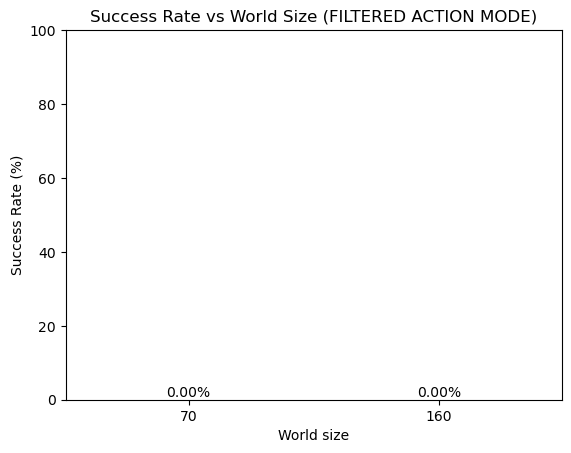

In [102]:
plt.figure()

bars = plt.bar(
    df_filtered["world_size"].astype(str),
    df_filtered["success_rate"]
)

plt.xlabel("World size")
plt.ylabel("Success Rate (%)")
plt.title("Success Rate vs World Size (FILTERED ACTION MODE)")

#✨ Force Y-axis to 0–100% with clean tick marks
plt.ylim(0, 100)
plt.yticks([0, 20, 40, 60, 80, 100])

#✨ Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()


# Collision Rate Plot for FILTERED ACTION MODE

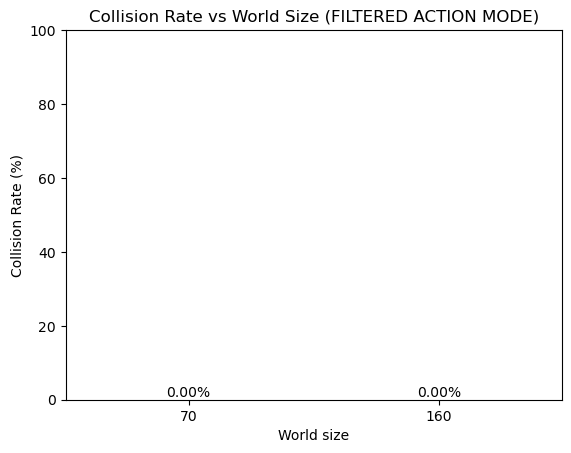

In [103]:
plt.figure()

bars = plt.bar(
    df_filtered["world_size"].astype(str),
    df_filtered["collision_rate"]
)

plt.xlabel("World size")
plt.ylabel("Collision Rate (%)")
plt.title("Collision Rate vs World Size (FILTERED ACTION MODE)")

# ✨ Set Y-axis to a fixed 0–100% range
plt.ylim(0, 100)
plt.yticks([0, 20, 40, 60, 80, 100])

# ✨ Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()


# Avg Steps Plot for for FILTERED ACTION MODE

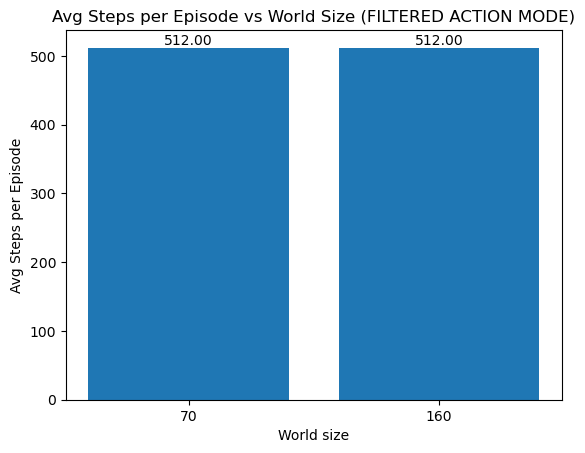

In [104]:
plt.figure()

bars = plt.bar(
    df_filtered["world_size"].astype(str),
    df_filtered["avg_steps"]
)

plt.xlabel("World size")
plt.ylabel("Avg Steps per Episode")
plt.title("Avg Steps per Episode vs World Size (FILTERED ACTION MODE)")

# ✨ Add value labels (only change requested)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()


# Agent Completion Rate Plot for  FILTERED ACTION MODE

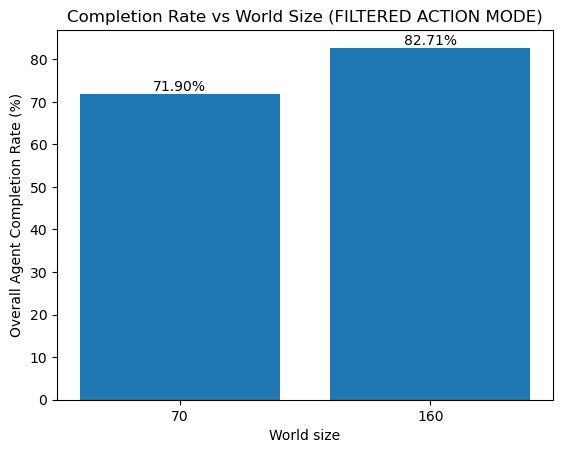

In [105]:
plt.figure()

bars = plt.bar(
    df_filtered["world_size"].astype(str),
    df_filtered["completion_rate"]
)

plt.xlabel("World size")
plt.ylabel("Overall Agent Completion Rate (%)")
plt.title("Completion Rate vs World Size (FILTERED ACTION MODE)")

# ✨ Add value labels (requested change)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()


### Comparison of RAW vs FILTERED Action Modes  
### World Sizes: 70×70 and 160×160


In [106]:
import re
import pandas as pd
import matplotlib.pyplot as plt


In [107]:
def parse_final_blocks(file_path):
    """
    Extract RAW ACTION MODE final results AND FILTERED ACTION MODE final results
    from a results .txt file.
    """

    patterns = {
        "success_rate": re.compile(r"Success Rate:\s*([0-9.]+)%"),
        "collision_rate": re.compile(r"Collision Rate:\s*([0-9.]+)%"),
        "avg_steps": re.compile(r"Avg Steps per Episode:\s*([0-9.]+)"),
        "completion_rate": re.compile(r"Overall Agent Completion Rate:\s*([0-9.]+)%"),
    }

    results = []

    with open(file_path, "r") as f:
        text = f.read()

    # Extract world size
    world_re = re.compile(r"World size:\s*(\d+)")
    m_world = world_re.search(text)
    world_size = int(m_world.group(1)) if m_world else None

    # Split into RAW and FILTERED sections
    raw_split = text.split("RAW ACTION MODE")
    if len(raw_split) < 2:
        raise ValueError("RAW ACTION MODE not found")

    filtered_split = text.split("FILTERED ACTION MODE")
    if len(filtered_split) < 2:
        raise ValueError("FILTERED ACTION MODE not found")

    # RAW final block
    raw_block = raw_split[1].split("ALL EXPERIMENTS DONE")[1]

    # FILTERED final block
    filtered_block = filtered_split[1].split("ALL EXPERIMENTS DONE")[1]

    # Helper function
    def extract(block, mode):
        row = {"mode": mode, "world_size": world_size}
        for key, pattern in patterns.items():
            m = pattern.search(block)
            if not m:
                raise ValueError(f"Missing {key} for mode={mode}")
            row[key] = float(m.group(1))
        return row

    results.append(extract(raw_block, "raw"))
    results.append(extract(filtered_block, "filtered"))

    return results


In [108]:
path_160 = "Experimental_results_of_Different_models/Hybrid_Standard_Learning_model/scalability_test_size160x160_agents_1000_obs_20_envs/scalability_test_size160x160_agents_1000_obs_20_results.txt"
path_70 = "Experimental_results_of_Different_models/Hybrid_Standard_Learning_model/scalability_test_size70x70_agents_1000_obs_20_envs/scalability_test_size70x70_agents_1000_obs_20_results.txt"

all_results = []
all_results += parse_final_blocks(path_70)
all_results += parse_final_blocks(path_160)

df_final = pd.DataFrame(all_results).sort_values(["mode", "world_size"])
df_final


,mode,world_size,success_rate,collision_rate,avg_steps,completion_rate
1,filtered,70,0.0,0.00,512.0,71.900
3,filtered,160,0.0,0.00,512.0,82.706
0,raw,70,0.0,4.91,512.0,70.800
2,raw,160,0.0,1.23,512.0,81.250


## Final Overall Results (RAW + FILTERED)

Below are the final summary metrics extracted from each file for each action mode.


In [109]:
df_final.style.format({
    "success_rate": "{:.2f}",
    "collision_rate": "{:.2f}",
    "avg_steps": "{:.2f}",
    "completion_rate": "{:.2f}",
})


,mode,world_size,success_rate,collision_rate,avg_steps,completion_rate
1,filtered,70,0.00,0.00,512.00,71.90
3,filtered,160,0.00,0.00,512.00,82.71
0,raw,70,0.00,4.91,512.00,70.80
2,raw,160,0.00,1.23,512.00,81.25


## Plots Comparing RAW vs FILTERED Modes Across World Sizes

We compare the two modes for the following metrics:

1. Success Rate  
2. Collision Rate  
3. Avg Steps per Episode  
4. Overall Agent Completion Rate  


# Success Rate (Raw vs Filter)

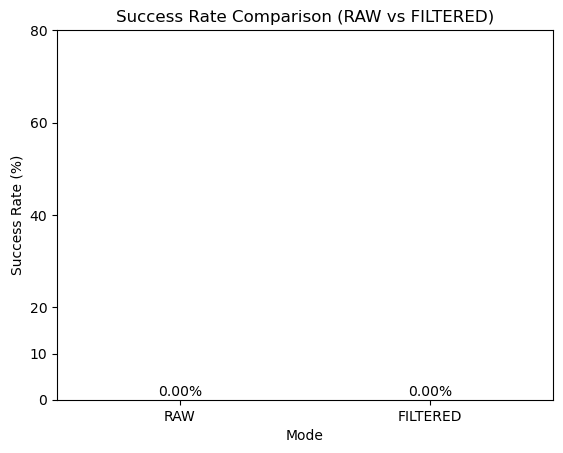

In [110]:
import numpy as np

plt.figure()

modes = ["RAW", "FILTERED"]
values = [
    df_final[df_final["mode"] == "raw"]["success_rate"].iloc[0],
    df_final[df_final["mode"] == "filtered"]["success_rate"].iloc[0]
]

bars = plt.bar(modes, values, color=["steelblue", "orange"])

plt.xlabel("Mode")
plt.ylabel("Success Rate (%)")
plt.title("Success Rate Comparison (RAW vs FILTERED)")

# Always show a clean percentage scale
plt.ylim(0, 5)
plt.yticks([0, 20, 40, 60, 80, 10])

# Add value labels
for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.1,              # slight lift above the bar
        f"{val:.2f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()


# Collision Rate (Raw vs Filter)

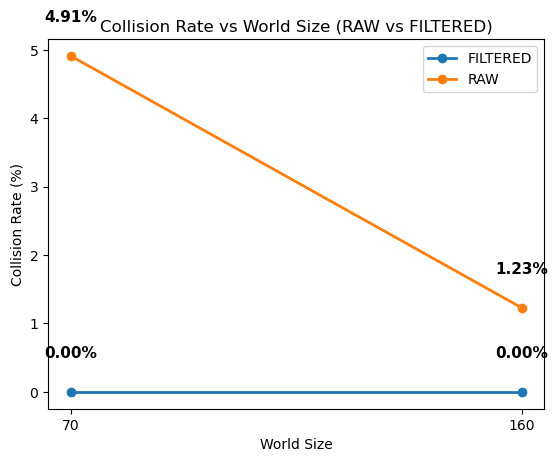

In [111]:
plt.figure()

for mode, d in df_final.groupby("mode"):
    # Ensure correct ordering
    d = d.sort_values("world_size")

    # Plot the line
    plt.plot(
        d["world_size"],
        d["collision_rate"],
        marker="o",
        linewidth=2,
        label=mode.upper()
    )

    # Add value labels ON the graph
    for x, y in zip(d["world_size"], d["collision_rate"]):
        plt.text(
            x, 
            y + 0.5,       # small raise to avoid overlapping the marker
            f"{y:.2f}%",
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

# X-axis ticks must be exactly 70 and 160
plt.xticks([70, 160], ["70", "160"])

plt.xlabel("World Size")
plt.ylabel("Collision Rate (%)")
plt.title("Collision Rate vs World Size (RAW vs FILTERED)")

plt.legend()

# Remove grid lines
plt.grid(False)

plt.show()


# Average Steps (Raw vs Filter)

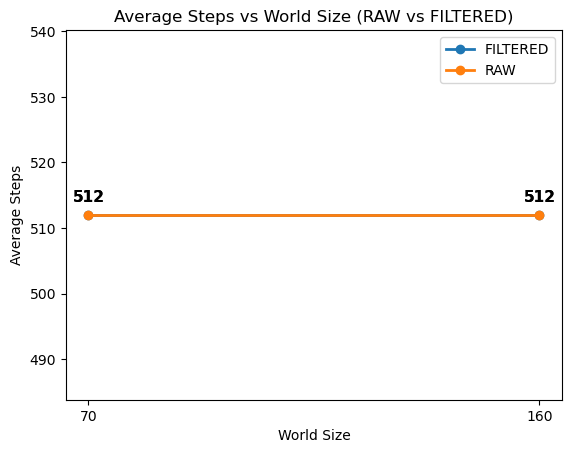

In [112]:
plt.figure()

for mode, d in df_final.groupby("mode"):
    d = d.sort_values("world_size")

    # Plot line
    plt.plot(
        d["world_size"],
        d["avg_steps"],
        marker="o",
        linewidth=2,
        label=mode.upper()
    )

    # Add value labels
    for x, y in zip(d["world_size"], d["avg_steps"]):
        plt.text(
            x,
            y + 2,                # small offset upward
            f"{y:.0f}",           # no decimals needed for steps
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

# Force x-axis labels 70 and 160
plt.xticks([70, 160], ["70", "160"])

plt.xlabel("World Size")
plt.ylabel("Average Steps")
plt.title("Average Steps vs World Size (RAW vs FILTERED)")

plt.legend()
plt.grid(False)            # remove grid lines

plt.show()


# Agent Completion_rate (Raw vs Filter)

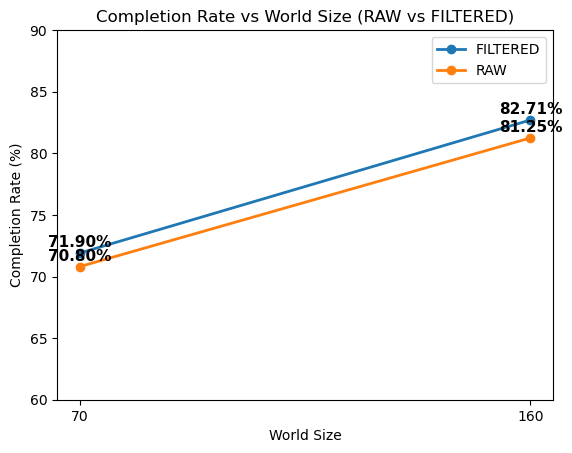

In [113]:
plt.figure()

for mode, d in df_final.groupby("mode"):
    d = d.sort_values("world_size")

    plt.plot(
        d["world_size"],
        d["completion_rate"],
        marker="o",
        linewidth=2,
        label=mode.upper()
    )

    # Add labels slightly above points
    for x, y in zip(d["world_size"], d["completion_rate"]):
        plt.text(
            x,
            y + 0.5,    # small offset
            f"{y:.2f}%",
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

# Force X-axis ticks
plt.xticks([70, 160], ["70", "160"])

# ⭐ FORCE Y-AXIS RANGE so labels never get cut
plt.ylim(60, 90)

plt.xlabel("World Size")
plt.ylabel("Completion Rate (%)")
plt.title("Completion Rate vs World Size (RAW vs FILTERED)")

plt.legend()
plt.grid(False)

plt.show()


# Final Conclusions: Scalability With Increasing World Size (70 → 160)
## Tested on RAW and FILTERED Action Modes

The purpose of scalability testing is to observe how performance changes as the world becomes larger, keeping agent counts and obstacle ratios constant across experiments.

World sizes compared:

- 70 × 70

- 160 × 160
# 1. Success Rate vs World Size

Across both world sizes and both action modes:

- Success Rate = 0%

This means no runs fully satisfied the success criteria regardless of environment size.

# 2. Collision Rate vs World Size
RAW Action Mode

- 70×70: Collision Rate = 4.91%

- 160×160: Collision Rate = 1.23%

➡️ As the world becomes larger, collisions decrease dramatically.
- A bigger environment provides more free space → fewer interactions → fewer collisions.

FILTERED Action Mode

- Collision Rate = 0% for both world sizes.

➡️ Filtered mode maintains perfect safety regardless of world size.

Scalability Impact:
- Collisions improve significantly with larger world size in RAW mode, while FILTERED mode scales perfectly with no collisions at all.

# 3. Average Steps vs World Size

Both world sizes consistently reached 512 max steps.

➡️ This means all agents ran until the step limit, indicating:

The environment size does not reduce the number of steps needed.

The navigation problem is still complex in larger worlds.

Scalability Impact:
- Average steps do not scale with world size – the system hits max steps anyway.

# 4. Agent Completion Rate vs World Size
RAW Mode

- 70×70: 70.80%

- 160×160: 81.25%

FILTERED Mode

- 70×70: 71.90%
 
- 160×160: 82.70%

➡️ Completion rate improves ~10% when world size increases.

A larger world allows:

- More room to maneuver

- Less agent congestion

- Higher probability of reaching goals

Scalability Impact:
- Completion rate scales positively with world size for both modes.